In [23]:
import pygame
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt
from matplotlib import animation
from collections import deque

print(torch.cuda.is_available())  # 應該為 True
print(torch.version.cuda)         # 應該列出 CUDA 版本
print(torch.backends.cudnn.version())  # cuDNN 版本
script_dir = os.path.join(os.getcwd(), 'space_ship_game_RL')
if script_dir not in sys.path:
    sys.path.append(script_dir)

from setting import *
from game import Game

True
11.8
90100


In [ ]:
class SpaceShipEnv():
    def __init__(self):
        pygame.init()
        pygame.font.init()

        # 延後畫面初始化，等 render() 時才設置
        self.screen = None
        self.clock = pygame.time.Clock()
        self.fps = FPS

        self.game = Game()

        self.action_space = [0, 1, 2, 3]
        self.observation = self.game.state

        self.in_cooldown = False                 # 自行在 __init__ 加這旗標
        self.cooldown_penalized = True           # 同上

    MAX_ROCK   = 5
    MAX_POWER  = 2
    MAX_SPD_X  = 3
    MAX_SPD_Y  = 10

    def _extract_state(self):
        p = self.game.player.sprite

        # -------- 玩家自身 --------
        px_norm   = p.rect.centerx / WIDTH
        hp_norm   = p.health / 100
        gun_oh    = [1 if i == p.gun - 1 else 0 for i in range(3)]
        cd_norm   = len(p.bullet_timer) / p.bullet_delay  # 0~1

        # -------- 石頭 (最近 10 顆) --------
        rocks = sorted(self.game.rocks,
                       key=lambda r: (r.rect.y - p.rect.y)**2 + (r.rect.x - p.rect.x)**2
                       )[:self.MAX_ROCK]

        rock_feats = []
        for r in rocks:
            dx = (r.rect.centerx - p.rect.centerx) / WIDTH
            dy = (r.rect.centery - p.rect.centery) / HEIGHT
            vx = r.speedx / self.MAX_SPD_X          # 約 -1~1
            vy = r.speedy / self.MAX_SPD_Y          # 約 0.2~1
            rr = r.radius / 40.0
            rock_feats += [dx, dy, vx, vy, rr]
        rock_feats += [0]*(self.MAX_ROCK*5 - len(rock_feats))  # padding

        # -------- 道具 (最近 2 顆) --------
        powers = sorted(self.game.powers,
                        key=lambda pw: abs(pw.rect.y - p.rect.y))[:self.MAX_POWER]

        power_feats = []
        for pw in powers:
            dx = (pw.rect.centerx - p.rect.centerx) / WIDTH
            dy = (pw.rect.centery - p.rect.centery) / HEIGHT
            tp = 1 if pw.type == 'shield' else -1   # shield=+1, gun=-1
            power_feats += [dx, dy, tp]
        power_feats += [0]*(self.MAX_POWER*3 - len(power_feats))

        # -------- 組合 --------
        state_vec = np.array(
            [px_norm, hp_norm] + gun_oh + [cd_norm] +
            rock_feats + power_feats,
            dtype=np.float32
        )
        return state_vec

    # ---- 超參數（一次集中管理） ----
    TIME_PENALTY = -0.3
    ALPHA_HIT      = 1.4           # 其實已併入 delta_score，可設 1
    LAMBDA_COLL    = 1.2           # 撞擊倍率
    # ---- 冷卻期 shaping ----
    MISS_SHOT_PENALTY = -1     # 空槍
    COOLDOWN_BONUS    = 0.5     # 射後等待

    def step(self, action):
        # ----- 0. 撞擊前狀態 -----
        player       = self.game.player.sprite
        ready_before = player.bullet_ready
        was_shooting  = (action == 1)
        hp_before    = player.health    
        score_before = self.game.score
        
        # ----- 1. 更新遊戲 -----
        self.game.update(action)

        ready_after  = player.bullet_ready          # ★update 後
        fired_now    = was_shooting and ready_before  # 這幀真的發射

        if self.screen is None:
            self.game.draw()
        else:
            self.game.draw(self.screen)
            self.clock.tick(self.fps)

        # ----- 2. 計算 reward -----
        reward = self.TIME_PENALTY       # 基礎時間懲罰

        # (a) 擊破石頭
        delta_score = self.game.score - score_before
        reward += self.ALPHA_HIT * delta_score

        # (b) 撞擊懲罰（半徑 × 剩餘血量因子）
        if self.game.is_collided:
            hp_after  = self.game.player.sprite.health
            radius    = hp_before - hp_after                # = damage = radius
            factor    = 2 - hp_after / 100                  # 滿血1 → 殘血2
            penalty   = self.LAMBDA_COLL * radius * factor
            reward   -= penalty

        # (c) 撿道具（依前述 shield +γ·hp_gain, gun +5）
        if self.game.is_power:
            hp_gain = self.game.player.sprite.health - hp_before
            reward += hp_gain                        # shield +20
            if hp_gain == 0:                               # gun
                reward += 12


        # -- 冷卻開始：扣一次 --
        if fired_now:
            self.in_cooldown = True                 # 自行在 __init__ 加這旗標
            self.cooldown_penalized = False         # 同上

        if was_shooting and not ready_before:       # 狂按但未射出
            if not self.cooldown_penalized:
                reward += self.MISS_SHOT_PENALTY         # 只扣一次
                self.cooldown_penalized = True

        # -- 冷卻結束：加一次 --
        if self.in_cooldown and ready_after:
            reward += self.COOLDOWN_BONUS
            self.in_cooldown = False                # 重置旗標

        # ----- 3. 其餘回傳 -----
        done  = (not self.game.running) or (self.game.score >= 10000)
        info  = self.game.score
        state = self._extract_state()

        return state, reward, done, info

    def reset(self):
        self.game = Game()
        self.in_cooldown = False          # ★
        self.cooldown_penalized = True    # ★
        return self._extract_state()

    def render(self):
        if self.screen is None:
            self.screen = pygame.display.set_mode((WIDTH, HEIGHT))
            pygame.display.set_caption("SpaceShip RL Environment")

    def close(self):
        pygame.quit()


In [25]:
# Hyperparameters
num_episodes = 4000
batch_size = 64
gamma = 0.99
lr = 1e-4
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 0.999
memory_capacity = 60000  # 100000
target_update_freq = 2000   # 1000

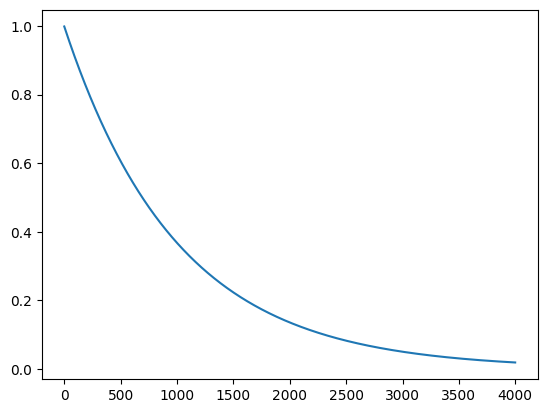

In [26]:
epsilon_list=[]
epsilon=epsilon_start
for i in range(num_episodes):
    epsilon = max(epsilon_end, epsilon * epsilon_decay)
    epsilon_list.append(epsilon)
plt.plot(epsilon_list)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [28]:
class MLPDQN(nn.Module):
    def __init__(self, input_dim, num_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_actions)
        )
    def forward(self, x):
        return self.net(x)

In [29]:
class ReplayMemory:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # 全存成 numpy，確保在 CPU，減少 GPU->CPU 來回
        self.buffer.append((
            state.cpu().numpy(),
            action,
            reward,
            next_state.cpu().numpy(),
            done
        ))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))

        states      = torch.tensor(states,      dtype=torch.float32, device=device)
        actions     = torch.tensor(actions,     dtype=torch.int64,   device=device)
        rewards     = torch.tensor(rewards,     dtype=torch.float32, device=device)
        next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
        dones       = torch.tensor(dones,       dtype=torch.float32, device=device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

In [ ]:
# 初始化 Breakout 環境 / Initialize the Breakout environment
env = SpaceShipEnv()
num_actions = len(env.action_space)
state_dim    = env._extract_state().shape[0]   # =37

policy_net   = MLPDQN(state_dim, num_actions).to(device)
target_net   = MLPDQN(state_dim, num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())  # 初始時讓目標網路等於策略網路
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
memory = ReplayMemory(memory_capacity)


if os.path.exists("checkpoint_ep1000.pth"):
    ckpt = torch.load("checkpoint_ep1000.pth", map_location=device)
    
    policy_net.load_state_dict(ckpt["policy_net"])
    # target_net.load_state_dict(ckpt["target_net"])
    target_net.load_state_dict(policy_net.state_dict())   # ★
    target_net.eval()                                     # 保持 eval
    optimizer.load_state_dict(ckpt["optimizer"])
    
    start_episode  = ckpt["episode"] + 1
    total_steps    = ckpt["total_steps"]
    best_avg_score = ckpt["best_avg_score"]
    best_avg_reward= ckpt["best_avg_reward"]
    epsilon        = max(0.2, ckpt["epsilon"]) 
    reward_history = ckpt['reward_history']
    score_history = ckpt['score_history']
    score_window  = deque(score_history[-100:],  maxlen=100)  # ★
    reward_window = deque(reward_history[-100:], maxlen=100)  # ★
    print(f"Loaded checkpoint from episode {start_episode}, best_avg_score: {best_avg_score:.2f}, epsilon={epsilon:.3f}")
else:
    start_episode = 0
    total_steps = 0
    best_score = float('-inf')
    epsilon = epsilon_start
    reward_history = []
    score_history = []

    score_window   = deque(maxlen=100)
    reward_window  = deque(maxlen=100)
    best_avg_score = float('-inf')
    best_avg_reward = float('-inf')


# 訓練迴圈 / Training loop
# 每次可以訓練個100步(根據自己的設備與時間調整)，然後下一次都再接續上次的訓練模型接續往下訓練
# You can train for 100 steps each time (adjust according to your own equipment and time),
# and then continue training from the last training model next time.
for episode in range(start_episode, 4000):
    state_np = env.reset()
    state    = torch.tensor(state_np, dtype=torch.float32, device=device)
    total_reward, done = 0.0, False

    while not done:
        # ---------- ε-greedy ----------
        if random.random() < epsilon:
            action = random.randrange(num_actions)
        else:
            with torch.no_grad():
                action = policy_net(state.unsqueeze(0)).argmax(1).item()

        # ---------- 執行動作 ----------
        next_state_np, reward, done, score = env.step(action)
        next_state = torch.tensor(next_state_np, dtype=torch.float32, device=device)

        total_reward += reward
        memory.push(state, action, reward, next_state, done)

        state = next_state

        # ---------- 取 batch 訓練 ----------
        if len(memory) >= batch_size:
            states, actions, rewards, next_states, dones = memory.sample(batch_size)

            with torch.no_grad():
                next_act = policy_net(next_states).argmax(1).unsqueeze(1)       # ★
                next_q   = target_net(next_states).gather(1, next_act).squeeze(1) # ★
                target_q = rewards + gamma * next_q * (1 - dones)              # ★

            current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
            loss = F.mse_loss(current_q, target_q)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10)
            optimizer.step()

        # ---------- 更新 target ----------
        total_steps += 1
        if total_steps % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

    # 更新 epsilon 並紀錄統計資料 / Decay epsilon and log results
    epsilon = max(epsilon_end, epsilon * epsilon_decay)
    reward_history.append(total_reward)
    score_history.append(score)
    
    score_window.append(score)
    reward_window.append(total_reward)

    avg_score  = sum(score_window)  / len(score_window)
    avg_reward = sum(reward_window) / len(reward_window)

    print(f"E{episode+1:4d} | R:{total_reward:7.2f} | S:{score:5.0f} "
          f"| AvgR:{avg_reward:6.1f} | AvgS:{avg_score:6.0f} | ε:{epsilon:.3f}")

    # ---------- ★ 1. 儲存 best 平均 Score ----------
    if avg_score > best_avg_score and len(score_window)==100:
        best_avg_score = avg_score
        torch.save(policy_net.state_dict(), "best_avg_score.pth")
        print(f"  ↑ New best 100-avg SCORE: {best_avg_score:.1f} saved.")

    # ---------- ★ 2. 儲存 best 平均 Reward ----------
    if avg_reward > best_avg_reward and len(reward_window)==100:
        best_avg_reward = avg_reward
        torch.save(policy_net.state_dict(), "best_avg_reward.pth")
        print(f"  ↑ New best 100-avg REWARD: {best_avg_reward:.1f} saved.")

    # ---------- ★ 3. 每 50 集完整 checkpoint ----------
    if (episode + 1) % 50 == 0:
        ckpt_path = f"checkpoint_ep{episode+1:04d}.pth"
        torch.save({
            "policy_net": policy_net.state_dict(),
            "target_net": target_net.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "epsilon":    epsilon,
            "episode":    episode,
            "total_steps": total_steps,
            "best_avg_score":  best_avg_score,
            "best_avg_reward": best_avg_reward,
            'reward_history': reward_history,
            'score_history': score_history,
        }, ckpt_path)

        print(f"  ⌁ 50-ep checkpoint saved to {ckpt_path}")

env.close()

Loaded checkpoint from episode 1000, best_avg_score: 2157.44, epsilon=0.100


KeyboardInterrupt: 

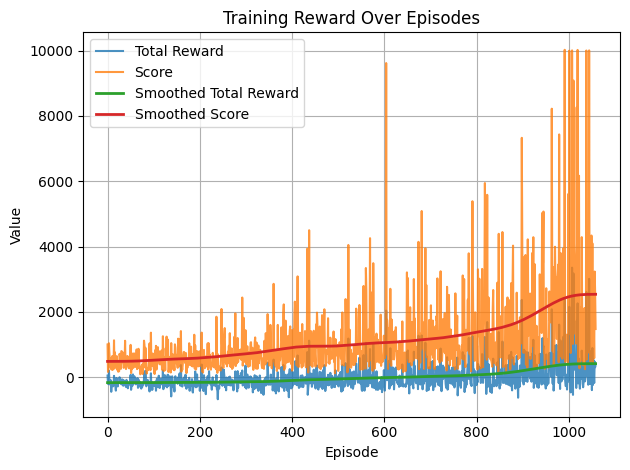

In [ ]:
from scipy.ndimage import gaussian_filter1d

reward_smooth = gaussian_filter1d(reward_history, sigma=50)
score_smooth = gaussian_filter1d(score_history, sigma=50)

# 畫圖
# plt.figure(figsize=(10, 5))
plt.plot(reward_history, label='Total Reward', alpha=0.8)
plt.plot(score_history, label='Score', alpha=0.8)
plt.plot(reward_smooth, label='Smoothed Total Reward', linewidth=2)
plt.plot(score_smooth, label='Smoothed Score', linewidth=2)

plt.legend(loc='upper left')
plt.xlabel("Episode")
plt.ylabel("Value")
plt.title("Training Reward Over Episodes")
plt.grid(True)
plt.tight_layout()
# plt.savefig("dqn_training_curve.png")

